# Predicción de ataque al corazón (Clasificación)

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [62]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [63]:
#Cargamos los datos
data=pd.read_csv('datos proyecto limpio.csv', sep=',')
data.head()

,avg_nitrogen_dioxide,max_time_nitrogen_dioxide,min_time_nitrogen_dioxide,min_ozone,max_time_ozone,min_time_ozone,avg_sulphur_dioxide,pm2_5_eaqi,min_temperature_2m,avg_relative_humidity_2m,sum_rain,avg_pressure_msl,avg_cloud_cover,avg_vapour_pressure_deficit,avg_wind_direction_100m,max_wind_gusts_10m,avg_soil_moisture_7_to_28cm,avg_direct_radiation,avg_terrestrial_radiation,eaqi
0,14.200000,08:00:00,16:00:00,9,17:00:00,07:00:00,3.387500,1,12.6,75.083333,0.1,1007.883333,76.125000,0.565000,171.250000,23.0,0.277125,88.000000,451.195833,1
1,18.437500,21:00:00,05:00:00,9,00:00:00,21:00:00,2.587500,1,12.2,85.291667,9.4,1010.920833,79.791667,0.254167,90.291667,40.7,0.280167,19.708333,452.916667,1
2,12.033333,23:00:00,16:00:00,37,18:00:00,09:00:00,2.504167,1,16.1,85.750000,45.3,1005.437500,94.250000,0.307917,111.958333,64.4,0.261750,23.958333,482.691667,1
3,16.766667,09:00:00,01:00:00,15,17:00:00,07:00:00,2.687500,1,14.3,89.250000,31.4,1007.291667,80.500000,0.208333,81.833333,32.4,0.382625,33.958333,483.266667,1
4,20.625000,23:00:00,04:00:00,9,19:00:00,08:00:00,2.637500,1,14.3,71.416667,0.1,1011.862500,29.875000,0.642500,254.500000,23.8,0.372375,82.958333,369.891667,1


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   avg_nitrogen_dioxide         1461 non-null   float64
 1   max_time_nitrogen_dioxide    1461 non-null   object 
 2   min_time_nitrogen_dioxide    1461 non-null   object 
 3   min_ozone                    1461 non-null   int64  
 4   max_time_ozone               1461 non-null   object 
 5   min_time_ozone               1461 non-null   object 
 6   avg_sulphur_dioxide          1461 non-null   float64
 7   pm2_5_eaqi                   1461 non-null   int64  
 8   min_temperature_2m           1461 non-null   float64
 9   avg_relative_humidity_2m     1461 non-null   float64
 10  sum_rain                     1461 non-null   float64
 11  avg_pressure_msl             1461 non-null   float64
 12  avg_cloud_cover              1461 non-null   float64
 13  avg_vapour_pressur

In [65]:
#Corrección tipos de datos
data['max_time_nitrogen_dioxide']=data['max_time_nitrogen_dioxide'].astype('category')
data['min_time_nitrogen_dioxide']=data['min_time_nitrogen_dioxide'].astype('category')
data['max_time_ozone']=data['max_time_ozone'].astype('category')
data['min_time_ozone']=data['min_time_ozone'].astype('category')
data['pm2_5_eaqi']=data['pm2_5_eaqi'].astype('category')
data['eaqi']=data['eaqi'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   avg_nitrogen_dioxide         1461 non-null   float64 
 1   max_time_nitrogen_dioxide    1461 non-null   category
 2   min_time_nitrogen_dioxide    1461 non-null   category
 3   min_ozone                    1461 non-null   int64   
 4   max_time_ozone               1461 non-null   category
 5   min_time_ozone               1461 non-null   category
 6   avg_sulphur_dioxide          1461 non-null   float64 
 7   pm2_5_eaqi                   1461 non-null   category
 8   min_temperature_2m           1461 non-null   float64 
 9   avg_relative_humidity_2m     1461 non-null   float64 
 10  sum_rain                     1461 non-null   float64 
 11  avg_pressure_msl             1461 non-null   float64 
 12  avg_cloud_cover              1461 non-null   float64 
 13  avg

<Axes: xlabel='eaqi'>

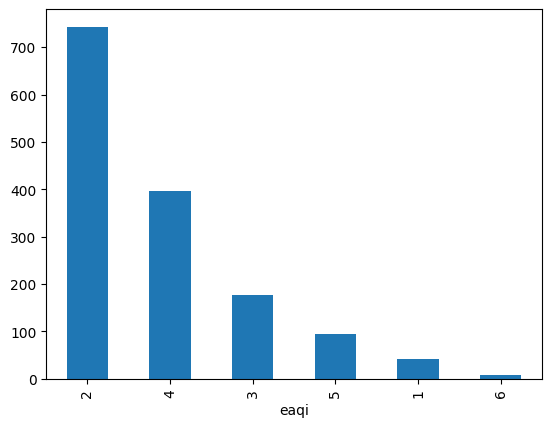

In [66]:
#Descripción variable objetivo
data['eaqi'].value_counts().plot(kind='bar')

In [67]:
print(data['eaqi'].value_counts().sort_index())
print(data.dtypes)

eaqi
1     41
2    743
3    178
4    397
5     94
6      8
Name: count, dtype: int64
avg_nitrogen_dioxide            float64
max_time_nitrogen_dioxide      category
min_time_nitrogen_dioxide      category
min_ozone                         int64
max_time_ozone                 category
min_time_ozone                 category
avg_sulphur_dioxide             float64
pm2_5_eaqi                     category
min_temperature_2m              float64
avg_relative_humidity_2m        float64
sum_rain                        float64
avg_pressure_msl                float64
avg_cloud_cover                 float64
avg_vapour_pressure_deficit     float64
avg_wind_direction_100m         float64
max_wind_gusts_10m              float64
avg_soil_moisture_7_to_28cm     float64
avg_direct_radiation            float64
avg_terrestrial_radiation       float64
eaqi                           category
dtype: object


In [68]:
from imblearn.over_sampling import SMOTENC
X = data.drop("eaqi", axis = 1)
Y = data['eaqi']
smote = SMOTENC(categorical_features=[1,2,4,5,7],k_neighbors=2,sampling_strategy={1: 200,3: 350,4: 500,5: 250,6: 80},random_state=42)

X_smote, y_smote = smote.fit_resample(X,Y)

<Axes: xlabel='eaqi'>

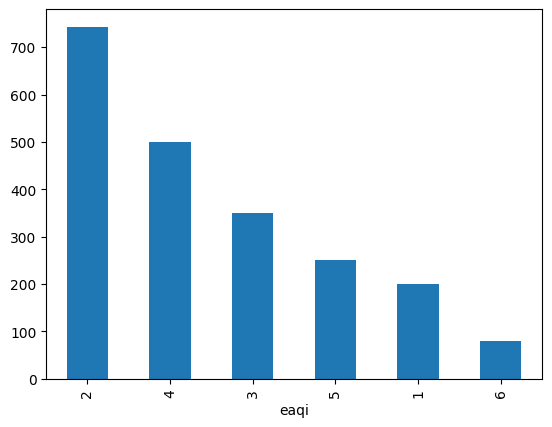

In [69]:
# Creamos un dataframe con los resultados (X_smote, y_smote)
data  = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)
data['eaqi']=y_smote
data['eaqi'].value_counts().plot(kind='bar')

In [70]:
# Cargar librería para Profiling
!pip install ydata-profiling

In [71]:
# Perfilado de datos
from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=False
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 51.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [72]:
#Dummies para variable con más de 2 categorías
data = pd.get_dummies(data, columns=['max_time_nitrogen_dioxide','min_time_nitrogen_dioxide','max_time_ozone','min_time_ozone','pm2_5_eaqi'], drop_first=False, dtype=int) #No se borra

data.head()

,avg_nitrogen_dioxide,min_ozone,avg_sulphur_dioxide,min_temperature_2m,avg_relative_humidity_2m,sum_rain,avg_pressure_msl,avg_cloud_cover,avg_vapour_pressure_deficit,avg_wind_direction_100m,...,min_time_ozone_20:00:00,min_time_ozone_21:00:00,min_time_ozone_22:00:00,min_time_ozone_23:00:00,pm2_5_eaqi_1,pm2_5_eaqi_2,pm2_5_eaqi_3,pm2_5_eaqi_4,pm2_5_eaqi_5,pm2_5_eaqi_6
0,14.200000,9,3.387500,12.6,75.083333,0.1,1007.883333,76.125000,0.565000,171.250000,...,0,0,0,0,1,0,0,0,0,0
1,18.437500,9,2.587500,12.2,85.291667,9.4,1010.920833,79.791667,0.254167,90.291667,...,0,1,0,0,1,0,0,0,0,0
2,12.033333,37,2.504167,16.1,85.750000,45.3,1005.437500,94.250000,0.307917,111.958333,...,0,0,0,0,1,0,0,0,0,0
3,16.766667,15,2.687500,14.3,89.250000,31.4,1007.291667,80.500000,0.208333,81.833333,...,0,0,0,0,1,0,0,0,0,0
4,20.625000,9,2.637500,14.3,71.416667,0.1,1011.862500,29.875000,0.642500,254.500000,...,0,0,0,0,1,0,0,0,0,0


# 2. División 70-30


<Axes: xlabel='eaqi'>

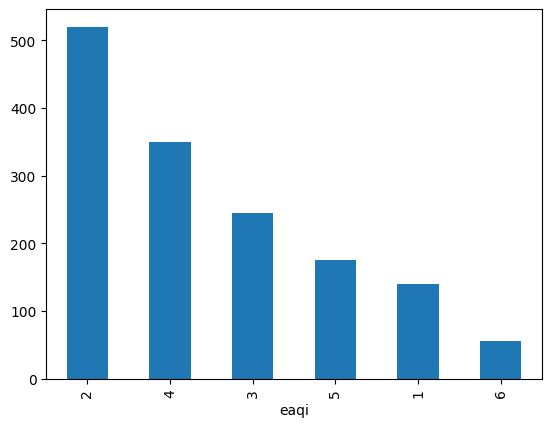

In [73]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("eaqi", axis = 1) # Variables predictoras
Y = data['eaqi'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado
Y_train.value_counts().plot(kind='bar')

<Axes: xlabel='eaqi'>

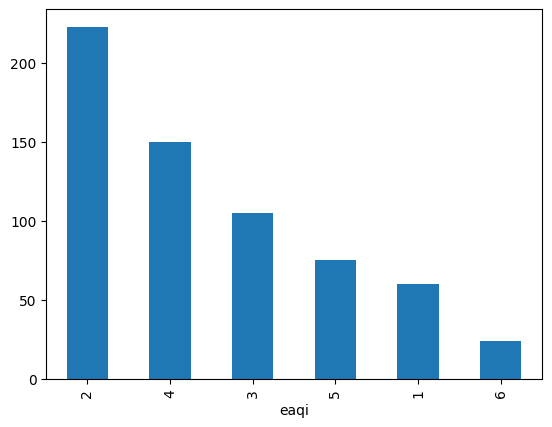

In [74]:
#Variable objetivo del 30%
Y_test.value_counts().plot(kind='bar')

# 3. Aprendizaje con el 70% y Evaluación con el 30%


# **Tree**
No se normaliza

In [75]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=2, max_depth=10) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train


DecisionTreeClassifier(max_depth=10, min_samples_leaf=2)

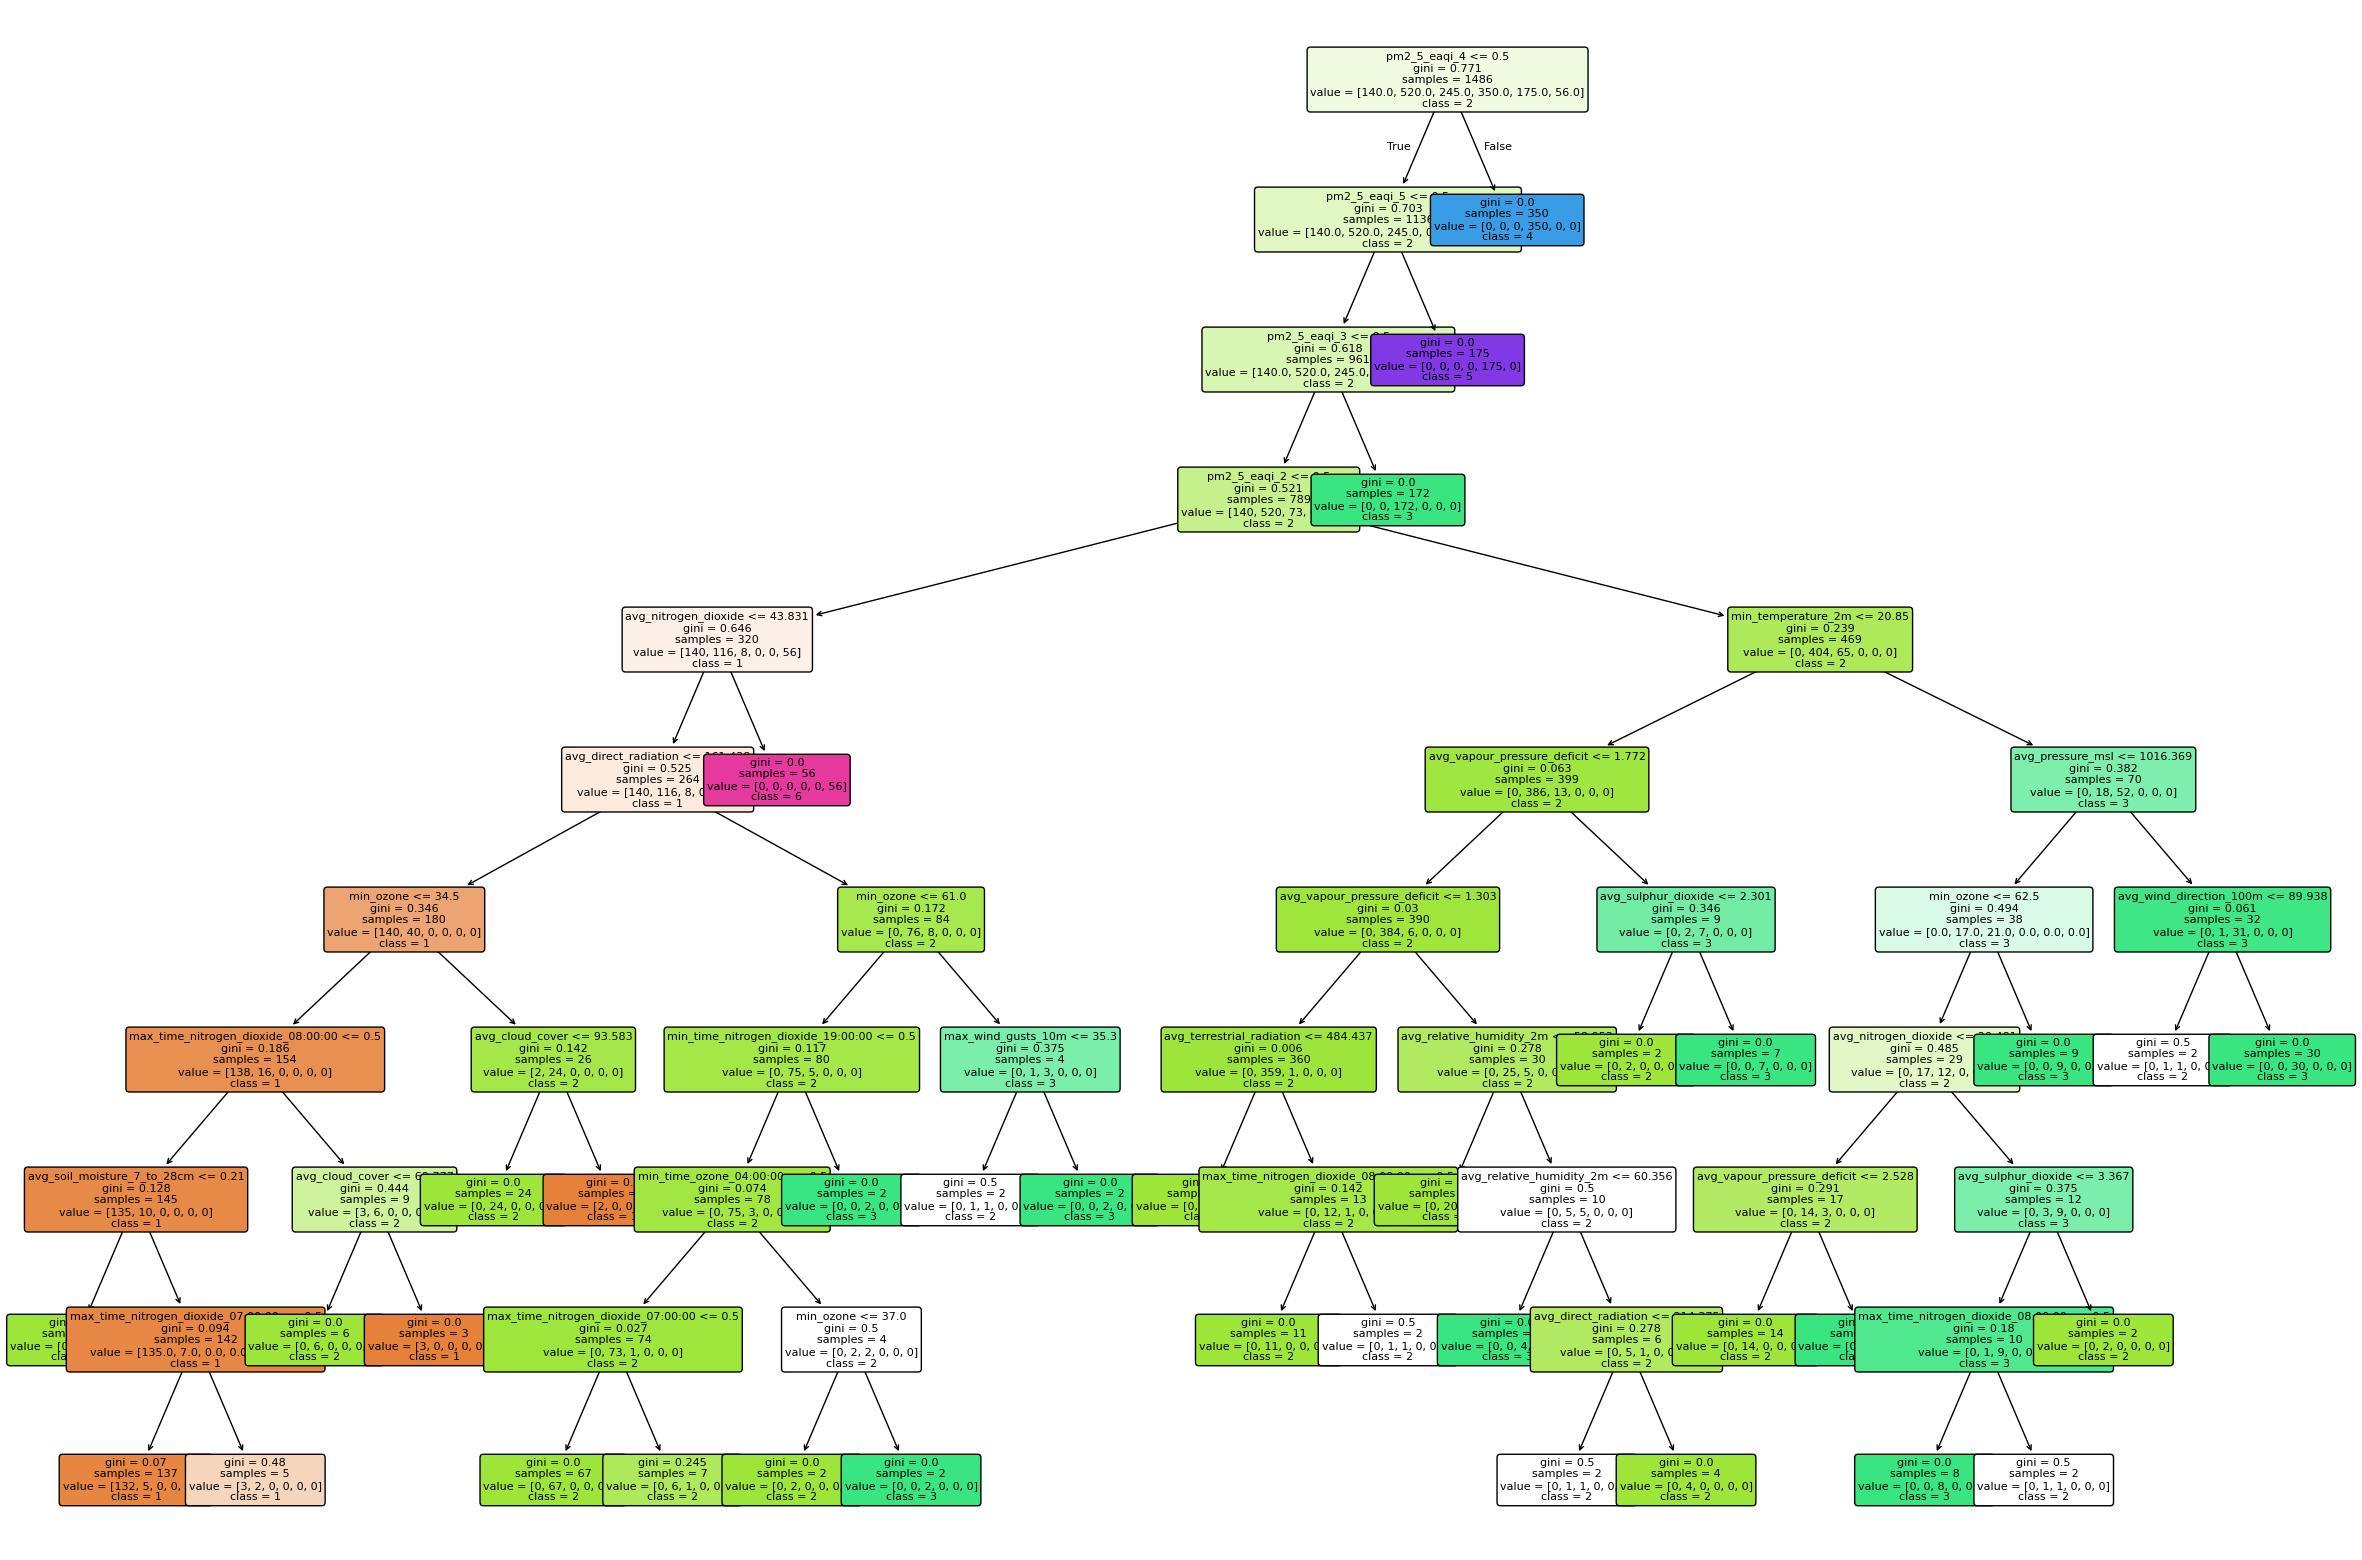

In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,20))

plot_tree(modelTree,feature_names=X_train.columns,class_names=['1','2','3','4','5','6'],filled=True,rounded=True,fontsize=8)

plt.show()

In [77]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[5 3 2 2 4 4 2 4 4 3 5 2 3 3 3 3 1 1 5 3 2 1 3 5 2 2 3 2 4 5 6 4 2 4 3 5 2
 5 3 2 2 2 1 2 3 4 1 3 3 5 1 4 2 4 3 2 1 1 4 4 5 1 6 2 2 4 2 4 4 2 5 2 3 5
 4 4 5 2 4 2 4 4 2 2 2 4 4 3 3 2 2 3 1 2 4 3 2 2 2 2 5 4 2 2 2 2 6 2 3 6 1
 2 4 1 2 5 1 5 2 5 6 1 4 2 5 4 4 2 2 6 6 4 3 1 5 3 3 4 3 2 4 3 3 2 2 6 6 3
 2 2 3 3 4 1 1 5 2 3 2 4 3 2 1 3 2 1 1 2 6 4 4 1 3 2 2 3 2 2 4 4 5 2 2 4 4
 3 2 4 2 4 2 4 2 5 2 3 4 4 4 4 2 2 4 2 4 2 2 3 2 2 3 2 2 4 3 4 5 6 3 2 5 2
 6 2 2 5 4 4 5 2 4 2 4 4 3 3 4 4 2 4 4 4 1 3 4 4 1 2 5 2 6 1 4 4 6 5 3 4 4
 4 2 2 4 2 5 2 1 5 3 5 3 4 3 2 3 1 4 2 1 3 2 3 2 3 4 1 3 2 5 1 2 4 2 5 5 5
 1 5 2 2 2 5 2 4 1 3 3 4 2 2 4 1 4 2 2 2 4 3 2 2 3 2 5 4 5 2 4 2 5 4 2 5 1
 2 5 5 5 2 3 4 4 4 2 3 1 4 1 2 3 2 4 5 2 2 2 4 5 1 2 3 4 2 1 2 5 1 1 4 4 3
 4 2 4 6 3 4 1 2 4 4 6 5 1 5 4 4 4 2 3 3 2 3 4 1 1 4 4 4 4 5 2 4 3 4 6 4 2
 2 2 2 2 5 5 5 3 2 4 5 5 5 2 3 1 3 2 2 2 5 6 5 4 5 2 3 3 2 2 4 3 4 4 6 1 4
 2 3 1 4 2 2 2 6 2 4 3 2 5 2 6 2 4 2 4 2 3 2 2 2 5 2 6 3 2 3 1 3 6 2 2 1 2
 2 2 2 5 3 3 3 3 5 2 4 3 

In [78]:
#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.9466248037676609


In [79]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[ 57,   3,   0,   0,   0,   0],
       [  5, 203,  14,   0,   0,   1],
       [  0,  11,  94,   0,   0,   0],
       [  0,   0,   0, 150,   0,   0],
       [  0,   0,   0,   0,  75,   0],
       [  0,   0,   0,   0,   0,  24]])

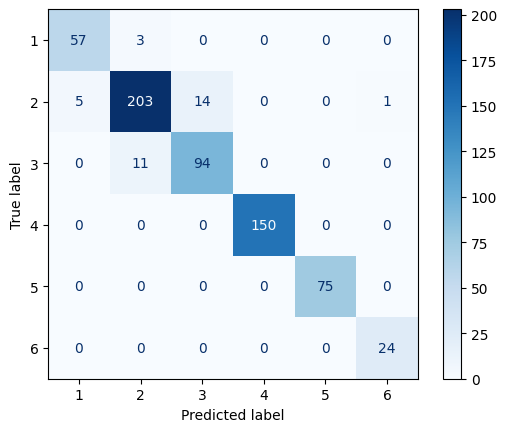

In [80]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['1','2','3','4','5','6'])
disp.plot(cmap='Blues')
plt.show()

In [81]:
#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=['1','2','3','4','5','6']))

              precision    recall  f1-score   support

           1       0.92      0.95      0.93        60
           2       0.94      0.91      0.92       223
           3       0.87      0.90      0.88       105
           4       1.00      1.00      1.00       150
           5       1.00      1.00      1.00        75
           6       0.96      1.00      0.98        24

    accuracy                           0.95       637
   macro avg       0.95      0.96      0.95       637
weighted avg       0.95      0.95      0.95       637



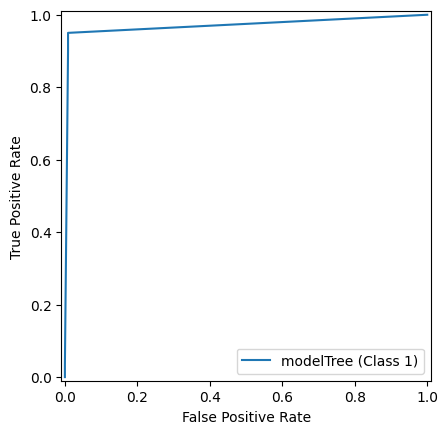

In [82]:
import matplotlib.pyplot as plt

# Assuming pos_label is already set to 1 in the previous attempt or we choose it
pos_label_value = 1 # The class we want to plot ROC for

# Get the probability scores for all classes
y_score_all_classes = modelTree.predict_proba(X_test)

# Get the index of the positive class from the model's classes
# modelTree.classes_ is an array, e.g., [1, 2, 3, 4, 5, 6]
pos_label_idx = modelTree.classes_.tolist().index(pos_label_value)

# Select the probability scores for the positive class
y_score = y_score_all_classes[:, pos_label_idx]

# Binarize the true labels for the positive class (one-vs-rest)
y_true_binary = (Y_test == pos_label_value).astype(int)

# Calculate FPR and TPR
fpr, tpr, thresholds = metrics.roc_curve(y_true_binary, y_score, pos_label=1)

# Plot the ROC curve
roc_display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'modelTree (Class {pos_label_value})')
roc_display.plot()
plt.show()

# **Red Neuronal**
- Normalizar

In [89]:

from sklearn.neural_network import MLPClassifier #MLPRegressor

#Hiperparámetros
#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones (cuidado con sobre-entrenamiento)
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="logistic",hidden_layer_sizes=(40), learning_rate='adaptive',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)

modelNN.fit(X_train, Y_train) #70% normalizados

MLPClassifier(activation='logistic', hidden_layer_sizes=40,
              learning_rate='adaptive', learning_rate_init=0.02, max_iter=500,
              momentum=0.03, random_state=3)

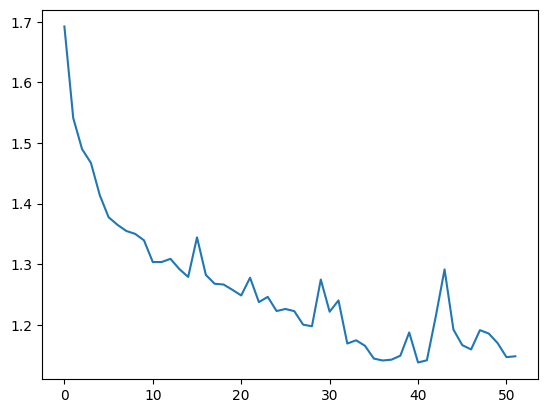

In [90]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = modelNN.loss_curve_
plt.plot(loss_values)

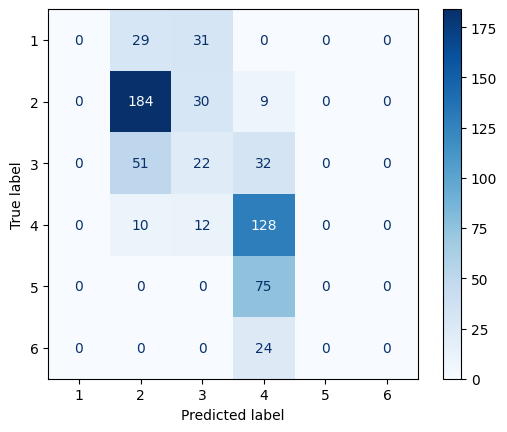

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        60
           2       0.67      0.83      0.74       223
           3       0.23      0.21      0.22       105
           4       0.48      0.85      0.61       150
           5       0.00      0.00      0.00        75
           6       0.00      0.00      0.00        24

    accuracy                           0.52       637
   macro avg       0.23      0.31      0.26       637
weighted avg       0.39      0.52      0.44       637



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


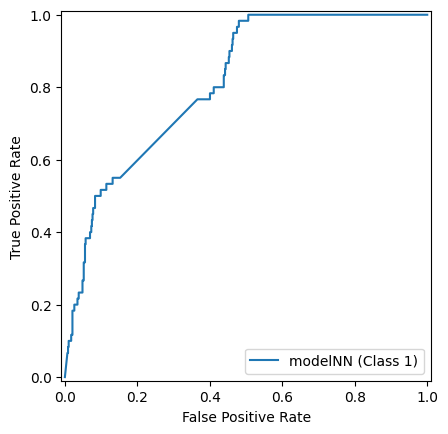

In [91]:
#Evaluación de Red Neuronal
from sklearn import metrics
import matplotlib.pyplot as plt

Y_pred = modelNN.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['1','2','3','4','5','6'])
disp.plot(cmap='Blues')
plt.show()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=['1','2','3','4','5','6']))

# Curva ROC (Modificado for multiclass)
pos_label_value = 1 # The class we want to plot ROC for (e.g., class '1')

# Get the probability scores for all classes
y_score_all_classes = modelNN.predict_proba(X_test)

# Get the index of the positive class from the model's classes
# modelNN.classes_ is an array, e.g., [1, 2, 3, 4, 5, 6]
pos_label_idx = modelNN.classes_.tolist().index(pos_label_value)

# Select the probability scores for the positive class
y_score = y_score_all_classes[:, pos_label_idx]

# Binarize the true labels for the positive class (one-vs-rest)
y_true_binary = (Y_test == pos_label_value).astype(int)

# Calculate FPR and TPR
fpr, tpr, thresholds = metrics.roc_curve(y_true_binary, y_score, pos_label=1)

# Plot the ROC curve
roc_display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'modelNN (Class {pos_label_value})')
roc_display.plot()
plt.show()

In [45]:
#Imprimir el modelo
print(modelNN.coefs_)  # W
print(modelNN.intercepts_) # b

[array([[-1.02858196e-01,  1.29600978e-01,  7.87423911e-09, ...,
        -5.79898416e-04, -1.49814289e-01, -1.77984789e-01],
       [-1.40065659e-01,  1.10298604e-01, -1.97677904e-20, ...,
         1.45495299e-01, -1.95206352e-01, -2.06910866e-01],
       [-1.90694538e-01,  3.48554212e-02, -3.24672729e-21, ...,
        -3.09928766e-19, -1.16325703e-01, -1.81279359e-01],
       ...,
       [-1.24679588e-01,  1.05243162e-22, -9.88089967e-21, ...,
        -1.48584210e-05, -4.94651528e-02,  2.74707152e-22],
       [ 4.00188714e-03,  7.65427518e-23,  4.56835175e-21, ...,
         9.75893882e-20, -4.17727222e-02,  4.60473724e-23],
       [-2.68521950e-23, -1.64874754e-23, -1.86392974e-21, ...,
        -1.00544437e-19,  3.90850404e-02,  2.96266088e-22]]), array([[-7.67941438e-02,  3.15227850e-02,  4.35405490e-02,
        -6.02134503e-02, -3.65983038e-02, -2.95581978e-01],
       [-2.28726158e-01, -5.01153321e-02,  1.76456851e-01,
         3.30490160e-01,  1.55697203e-01,  2.50261316e-02],
   

# **SVM**
-Normalizar

In [46]:
#SVM
from sklearn.svm import SVC # SVR

modelSVM = SVC(kernel='rbf',C=1,class_weight="balanced") #'linear', 'poly'->degree=3, 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVC(C=1, class_weight='balanced')

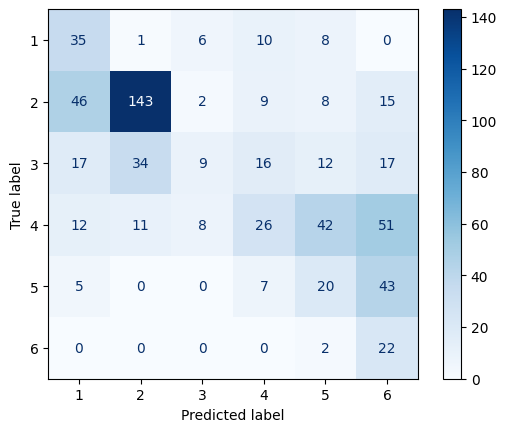

              precision    recall  f1-score   support

           1       0.30      0.58      0.40        60
           2       0.76      0.64      0.69       223
           3       0.36      0.09      0.14       105
           4       0.38      0.17      0.24       150
           5       0.22      0.27      0.24        75
           6       0.15      0.92      0.26        24

    accuracy                           0.40       637
   macro avg       0.36      0.44      0.33       637
weighted avg       0.47      0.40      0.40       637

Consider adding 'probability=True' to SVC constructor for proper probability outputs (e.g., SVC(..., probability=True)).


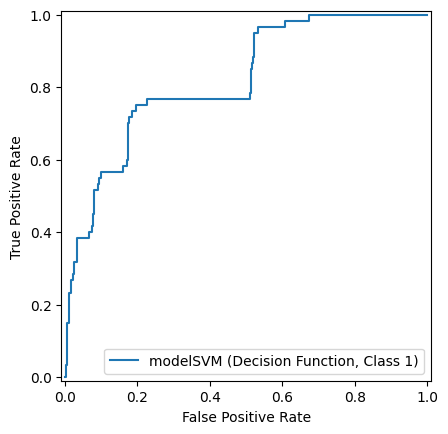

In [50]:
#Evaluación de SVM
from sklearn import metrics
import matplotlib.pyplot as plt

Y_pred = modelSVM.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['1','2','3','4','5','6'])
disp.plot(cmap='Blues')
plt.show()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=['1','2','3','4','5','6']))

# Curva ROC (Modificado for multiclass)
pos_label_value = 1 # The class we want to plot ROC for (e.g., class '1')

# Check if predict_proba is available, otherwise use decision_function
# SVC requires probability=True in its constructor to enable predict_proba
if hasattr(modelSVM, 'predict_proba') and modelSVM.probability:
    y_score_all_classes = modelSVM.predict_proba(X_test)
    pos_label_idx = modelSVM.classes_.tolist().index(pos_label_value)
    y_score = y_score_all_classes[:, pos_label_idx]
    roc_estimator_name = f'modelSVM (Probabilities, Class {pos_label_value})'
else:
    print("Warning: modelSVM was not initialized with probability=True. Using decision_function scores for ROC curve.")
    print("Consider adding 'probability=True' to SVC constructor for proper probability outputs (e.g., SVC(..., probability=True)).")
    # For multiclass SVC, decision_function returns scores per class (often one-vs-rest scores if decision_function_shape='ovr')
    # or pairwise scores. Based on kernel state, it appears to return (n_samples, n_classes).
    decision_scores = modelSVM.decision_function(X_test)
    class_index_in_model_classes = modelSVM.classes_.tolist().index(pos_label_value)
    y_score = decision_scores[:, class_index_in_model_classes]
    roc_estimator_name = f'modelSVM (Decision Function, Class {pos_label_value})'

# Binarize the true labels for the positive class (one-vs-rest)
y_true_binary = (Y_test == pos_label_value).astype(int)

# Calculate FPR and TPR
fpr, tpr, thresholds = metrics.roc_curve(y_true_binary, y_score, pos_label=1)

# Plot the ROC curve
roc_display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=roc_estimator_name)
roc_display.plot()
plt.show()

BAGGIN

In [57]:
#Bagging: Knn
from sklearn.ensemble import BaggingClassifier #BaggingRegressor
from sklearn.neighbors import KNeighborsClassifier # Import KNeighborsClassifier

modelo_base=KNeighborsClassifier(n_neighbors=1, metric='euclidean')

model_bag = BaggingClassifier(modelo_base, n_estimators=100, max_samples=0.6) #n_estimators=100
model_bag.fit(X_train, Y_train)#70%

#Evaluación
Y_pred = model_bag.predict(X_test) #30%
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=['1','2','3','4','5','6']))

              precision    recall  f1-score   support

           1       0.76      0.95      0.84        60
           2       0.83      0.75      0.79       223
           3       0.66      0.70      0.68       105
           4       0.72      0.65      0.68       150
           5       0.75      0.85      0.80        75
           6       0.96      1.00      0.98        24

    accuracy                           0.76       637
   macro avg       0.78      0.82      0.80       637
weighted avg       0.76      0.76      0.76       637



RANDOM FOREST

In [58]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
model_rf= RandomForestClassifier(n_estimators=100,  max_samples=0.7, criterion='gini',
                              max_depth=None, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%


#Evaluación
Y_pred = model_rf.predict(X_test) #30%
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=['1','2','3','4','5','6']))

              precision    recall  f1-score   support

           1       0.92      0.97      0.94        60
           2       0.94      0.97      0.96       223
           3       0.99      0.90      0.94       105
           4       1.00      1.00      1.00       150
           5       1.00      1.00      1.00        75
           6       1.00      1.00      1.00        24

    accuracy                           0.97       637
   macro avg       0.98      0.97      0.97       637
weighted avg       0.97      0.97      0.97       637



In [59]:
# Se imprimen la importancia de las características
print('Importancia de las características')
for i, j in sorted(zip(X_train.columns, model_rf.feature_importances_)):
    print(i, j)

Importancia de las características
avg_cloud_cover 0.02144133119963942
avg_direct_radiation 0.026674593915680403
avg_nitrogen_dioxide 0.06343132416600436
avg_pressure_msl 0.023479117376901
avg_relative_humidity_2m 0.024030679867657247
avg_soil_moisture_7_to_28cm 0.029298258860699523
avg_sulphur_dioxide 0.044821704097918226
avg_terrestrial_radiation 0.042249245225630255
avg_vapour_pressure_deficit 0.044995092926166776
avg_wind_direction_100m 0.01854307073231585
max_time_nitrogen_dioxide_00:00:00 0.001626588730119228
max_time_nitrogen_dioxide_01:00:00 0.0005311008789421113
max_time_nitrogen_dioxide_02:00:00 0.00019699286773975402
max_time_nitrogen_dioxide_03:00:00 4.570935623148141e-05
max_time_nitrogen_dioxide_04:00:00 0.0
max_time_nitrogen_dioxide_05:00:00 0.0
max_time_nitrogen_dioxide_06:00:00 0.0
max_time_nitrogen_dioxide_07:00:00 0.0005630592557435002
max_time_nitrogen_dioxide_08:00:00 0.002907446611142438
max_time_nitrogen_dioxide_09:00:00 0.0007464329555402181
max_time_nitrogen_di

# 5. Guardamos el mejor modelo
Se entrena modelo final con 100% de los datos (X,Y)

#El modelo que mejor trabaja es el random forest porque los valores de recall y precision fueron los mas altos.

In [ ]:
#si elige un tree o bayes no se normaliza y se comenta la siguiente linea
#Normalizar X en caso de ser necesario: Knn, NN, SVM, Reg
#X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [60]:
#Entrenamos modelo final
model_rf.fit(X, Y) #100%

RandomForestClassifier(max_samples=0.7, min_samples_leaf=2)

In [61]:
import pickle
filename = 'Modelo_Proyecto.pkl'
variables= X.columns._values
pickle.dump([model_rf,variables,], open(filename, 'wb'))
